# MNIST Neural Network

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

In [2]:
# Load and preprocess data
mnist = fetch_openml('mnist_784')
X = mnist.data.values
y = mnist.target.astype(int).values

# Normalize
X = X / 255.0

def one_hot(y):
    onehot = np.zeros((y.size, 10))
    onehot[np.arange(y.size), y] = 1
    return onehot

y = one_hot(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
# Activation functions
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return x > 0

def softmax(x):
    exp = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

In [4]:
# Initialize parameters
np.random.seed(42)

input_size = 784
hidden1 = 128
hidden2 = 64
output_size = 10

W1 = np.random.randn(input_size, hidden1) * 0.01
b1 = np.zeros((1, hidden1))

W2 = np.random.randn(hidden1, hidden2) * 0.01
b2 = np.zeros((1, hidden2))

W3 = np.random.randn(hidden2, output_size) * 0.01
b3 = np.zeros((1, output_size))

In [5]:
# Forward
def forward(X):
    z1 = X @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ W2 + b2
    a2 = relu(z2)
    z3 = a2 @ W3 + b3
    a3 = softmax(z3)
    return z1, a1, z2, a2, z3, a3

In [6]:
# Backward
def backward(X, y, z1, a1, z2, a2, z3, a3, lr=0.01):
    global W1, W2, W3, b1, b2, b3

    m = X.shape[0]

    dz3 = a3 - y
    dW3 = a2.T @ dz3 / m
    db3 = np.sum(dz3, axis=0, keepdims=True) / m

    dz2 = (dz3 @ W3.T) * relu_derivative(z2)
    dW2 = a1.T @ dz2 / m
    db2 = np.sum(dz2, axis=0, keepdims=True) / m

    dz1 = (dz2 @ W2.T) * relu_derivative(z1)
    dW1 = X.T @ dz1 / m
    db1 = np.sum(dz1, axis=0, keepdims=True) / m

    W3 -= lr * dW3
    b3 -= lr * db3

    W2 -= lr * dW2
    b2 -= lr * db2

    W1 -= lr * dW1
    b1 -= lr * db1

In [7]:
# Training with mini-batch
epochs = 50
batch_size = 64
learning_rate = 0.01

for epoch in range(epochs):
    perm = np.random.permutation(X_train.shape[0])
    X_train = X_train[perm]
    y_train = y_train[perm]

    for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]

        z1, a1, z2, a2, z3, a3 = forward(X_batch)
        backward(X_batch, y_batch, z1, a1, z2, a2, z3, a3, learning_rate)

    if epoch % 10 == 0:
        loss = -np.mean(np.sum(y_batch * np.log(a3 + 1e-8), axis=1))
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 0, Loss: 2.2985
Epoch 10, Loss: 0.4174
Epoch 20, Loss: 0.2347
Epoch 30, Loss: 0.2267
Epoch 40, Loss: 0.1612


In [8]:
# Testing
_, _, _, _, _, pred = forward(X_test)

pred_labels = np.argmax(pred, axis=1)
true_labels = np.argmax(y_test, axis=1)

accuracy = np.mean(pred_labels == true_labels)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.9637857142857142


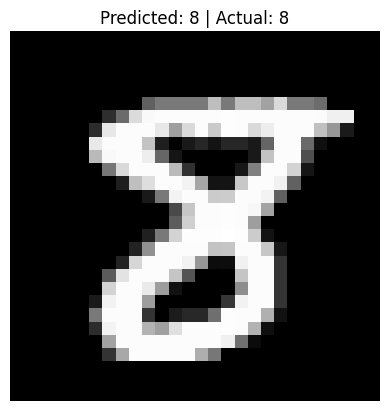

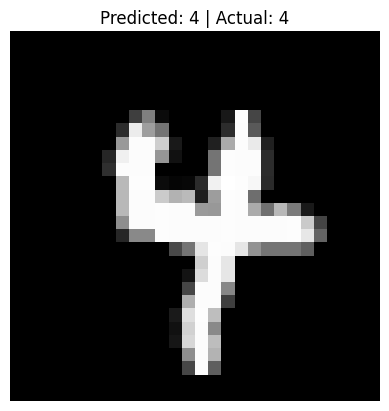

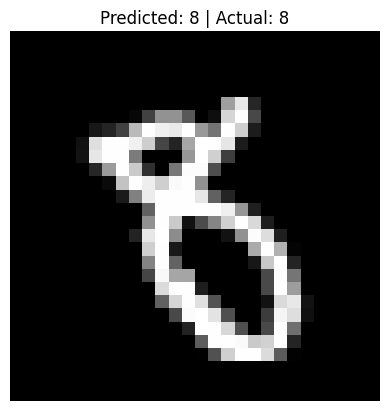

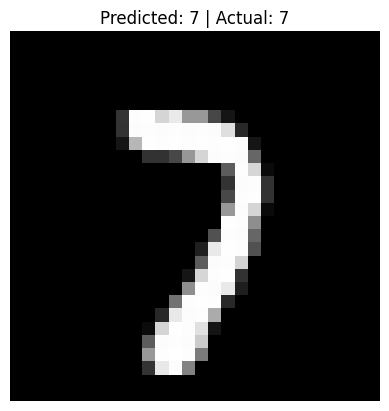

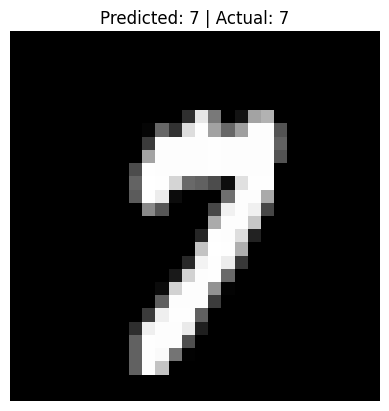

In [9]:
# Visualization
for i in range(5):
    image = X_test[i].reshape(28, 28)
    plt.imshow(image, cmap='gray')
    plt.title(f"Predicted: {pred_labels[i]} | Actual: {true_labels[i]}")
    plt.axis('off')
    plt.show()